# Replay single-cell BO offline from an existing run

Takes an existing `exp_data.parquet` (produced by
`utils.generate_exp_data_from_tracks(...)`), replays the single-cell
preprocessing + BO acquisition phase-by-phase, and produces the 1×3
live-summary plot (measured points | GP predicted landscape |
acquisition EI) for each phase.

**No microscope, no imaging** — this is purely offline analysis of
a completed run, useful for:

1. Checking what the **new** single-cell BO *would have* picked if
   it had been driving the run (instead of the FOV-level v4 BO).
2. Tuning the classifier thresholds / quality gates retrospectively
   before committing to them in the live experiment.
3. Visualising per-phase acquisition landscapes for diagnosis.

**Backend:** defaults to gpax `viSparseGP` (handles thousands of
cells); flip `USE_BOTORCH=True` to use `OscillationBOSingleCellBoTorch`
(ExactGP — fine for small replays, slow above ~3000 cumulative cells).

In [11]:
import os, glob, importlib.util
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ---- gpax/numpyro compat shim (matches live notebook) ----
import numpyro.contrib.module as _ncm


def _haiku_unavailable(*_args, **_kwargs):
    raise NotImplementedError("haiku removed")


if not hasattr(_ncm, "random_haiku_module"):
    _ncm.random_haiku_module = _haiku_unavailable
if not hasattr(_ncm, "haiku_module"):
    _ncm.haiku_module = _haiku_unavailable

# ---- User config ----
USE_BOTORCH = True  # True -> OscillationBOSingleCellBoTorch

# Path to the completed live run (must contain tracks/ and exp_data.parquet)
RUN_PATH = r"E:\Alex\2026-04-10_bo_erk_oscillation_v4_test"
EXP_DATA_PATH = os.path.join(RUN_PATH, "exp_data.parquet")

# Must match what the original run used
N_FRAMES_BASELINE = 10
N_FRAMES_STIM = 60
N_FRAMES_RECOVERY = 20
N_FRAMES = N_FRAMES_BASELINE + N_FRAMES_STIM + N_FRAMES_RECOVERY
FIRST_FRAME_STIM = N_FRAMES_BASELINE
LAST_FRAME_STIM = FIRST_FRAME_STIM + N_FRAMES_STIM

CLASSIFIER_PATH = r"./oscillation_model_60min.joblib"
CLASSIFIER_SCRIPT = r"./apply_oscillation_classifier_v2.py"

N_CONDITIONS_PER_ITER = 2
N_INITIAL_PHASES = 2

In [12]:
import joblib

model_data = joblib.load(CLASSIFIER_PATH)
osc_clf = model_data["clf"]
osc_scaler = model_data["scaler"]
osc_feature_cols = model_data["feature_cols"]
osc_cfg = model_data["config"]
osc_cfg["window_size"] = model_data["window_size"]
osc_cfg["window_step"] = model_data["window_step"]

_spec = importlib.util.spec_from_file_location("osc_clf_mod", CLASSIFIER_SCRIPT)
_mod = importlib.util.module_from_spec(_spec)
_spec.loader.exec_module(_mod)
predict_trace = _mod.predict_trace

In [13]:
# --- Load exp_data.parquet ---
# Expected columns: particle, fov, phase_id, fov_timestep, cnr (or cnr_median),
# ref_mean_intensity, x, y, etc.
df_exp = pd.read_parquet(EXP_DATA_PATH)
print(f"Loaded {len(df_exp)} rows, columns: {list(df_exp.columns)}")
print(f"Phases in data: {sorted(df_exp['phase_id'].unique())}")
print(
    f"FOVs: {df_exp['fov'].nunique()}, unique (phase, fov): "
    f"{df_exp.groupby(['phase_id','fov']).ngroups}"
)

Loaded 688761 rows, columns: ['label', 'x', 'y', 'phase_name', 'phase_id', 'condition_idx', 'stim_exposure', 'ramp', 'fov', 'timestep', 'fname', 'time', 'stim', 'channels', 'ref_channels', 'time_acquired', 'fov_timestep', 'img_shape', 'particle', 'mean_intensity_C0_nuc', 'mean_intensity_C1_nuc', 'area_nuc', 'median_intensity_C0_nuc', 'median_intensity_C1_nuc', 'mean_intensity_C0_ring', 'mean_intensity_C1_ring', 'median_intensity_C0_ring', 'median_intensity_C1_ring', 'cnr_mean', 'cnr', 'stim_power', 'ref_mean_intensity', 'time_offset']
Phases in data: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8)]
FOVs: 162, unique (phase, fov): 162


In [14]:
# --- Condition map: recover (stim_exposure, ramp) per FOV from the data ---
# Each FOV should have a single (stim_exposure, ramp) for all its frames.
cond_map_df = (
    df_exp.groupby(["phase_id", "fov"])
    .agg(stim_exposure=("stim_exposure", "first"), ramp=("ramp", "first"))
    .reset_index()
)
print(cond_map_df.head())
print(
    f"Phases: {cond_map_df['phase_id'].nunique()}, "
    f"unique conditions: {cond_map_df[['stim_exposure','ramp']].drop_duplicates().shape[0]}"
)

   phase_id  fov  stim_exposure  ramp
0         0    0           75.0  15.0
1         0    1           75.0  15.0
2         0    2           75.0  15.0
3         0    3           75.0  15.0
4         0    4           75.0  15.0
Phases: 9, unique conditions: 18


In [15]:
# --- Instantiate the single-cell BO agent offline (no microscope) ---
from faro.agents.bo_optimization import BO_Parameter, BO_Objective, BO_Covariate

if USE_BOTORCH:
    from faro.agents.bo_oscillation_single_cell_botorch import (
        OscillationBOSingleCellBoTorch as AgentClass,
    )

    backend_kwargs = {}
else:
    from faro.agents.bo_oscillation_single_cell import (
        OscillationBOSingleCell as AgentClass,
    )

    backend_kwargs = dict(
        gp_backend="vi_sparse",
        inducing_points_ratio=0.1,
        num_svi_steps=1500,
        svi_step_size=5e-3,
        gp_batch_size=2000,
    )

bo_params = [
    BO_Parameter(name="stim_exposure", bounds=(50.0, 500.0), spacing=25.0),
    BO_Parameter(name="ramp", bounds=(0.0, 20.0), spacing=5.0),
]

bo_covariates = [
    BO_Covariate(name="baseline_cnr"),
    BO_Covariate(name="optortk_expression"),
    BO_Covariate(name="mean_dist_k_nearest"),
]
bo_objective = BO_Objective(name="mean_osc_probability", goal="maximize")

storage_path = os.path.join(RUN_PATH, "replay_single_cell")
os.makedirs(storage_path, exist_ok=True)

agent = AgentClass(
    storage_path=storage_path,
    n_frames=N_FRAMES,
    first_frame_stim=FIRST_FRAME_STIM,
    last_frame_stim=LAST_FRAME_STIM,
    time_between_timesteps=60,
    imaging_channels=(),
    stim_channel=None,
    optocheck_channel=None,
    osc_clf=osc_clf,
    osc_scaler=osc_scaler,
    osc_feature_cols=osc_feature_cols,
    osc_cfg=osc_cfg,
    osc_predict_fn=predict_trace,
    min_osc_probability=0.0,
    min_consecutive_windows=0,
    min_fft_amplitude=0.0,
    n_baseline_frames=N_FRAMES_BASELINE,
    density_k_neighbours=5,
    parameters_to_optimize=bo_params,
    objective_metric=bo_objective,
    bo_covariates=bo_covariates,
    n_iterations=cond_map_df["phase_id"].nunique(),
    n_conditions_per_iter=N_CONDITIONS_PER_ITER,
    n_initial_phases=N_INITIAL_PHASES,
    acquisition_function="ei",
    n_cov_samples=20,
    ei_xi=0.2,
    ei_xi_final=0.01,
    ei_xi_decay_fraction=0.7,
    plot_live=False,  # we manually render per-phase plots below
    save_checkpoints=False,
    verbose=True,
    **backend_kwargs,
)
print(f"Agent: {type(agent).__name__}")

Agent: OscillationBOSingleCellBoTorch



===== Replaying phase 0 =====
  Phase 0: 655 cells (from 18 FOVs), mean mean_osc_probability=0.1092, max=0.9960


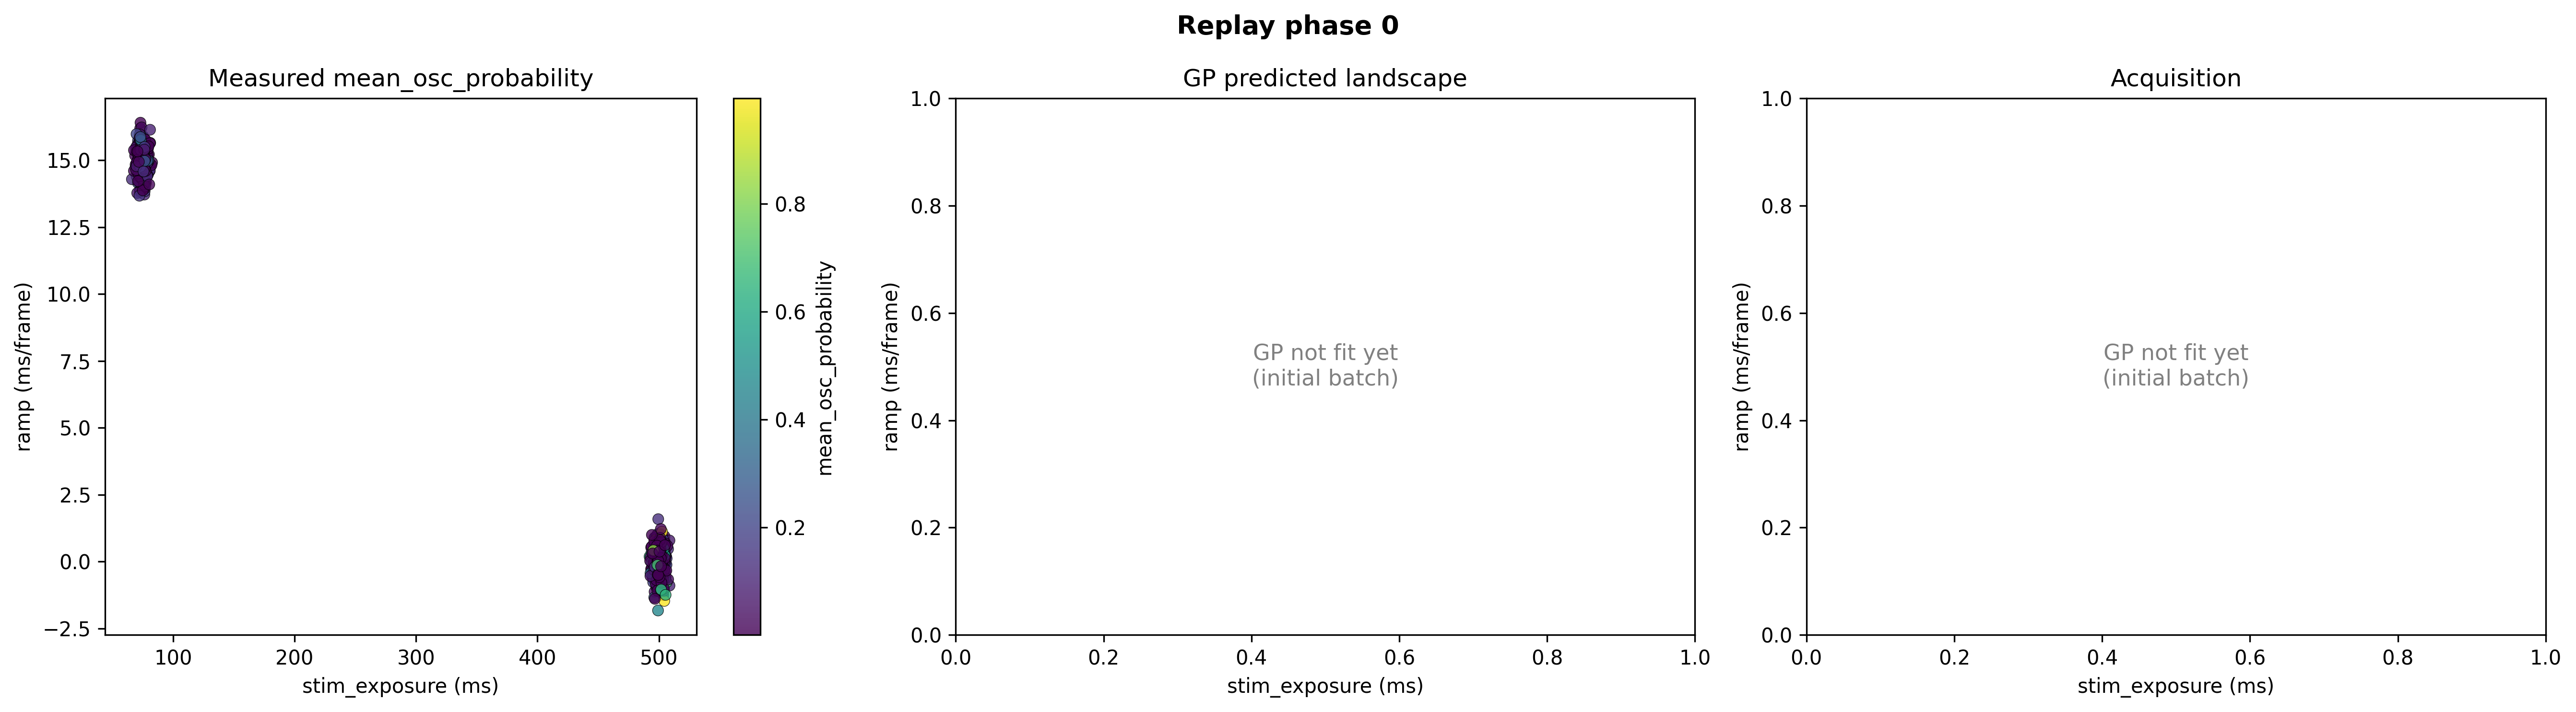


===== Replaying phase 1 =====
  Phase 1: 285 cells (from 17 FOVs), mean mean_osc_probability=0.1577, max=0.9805


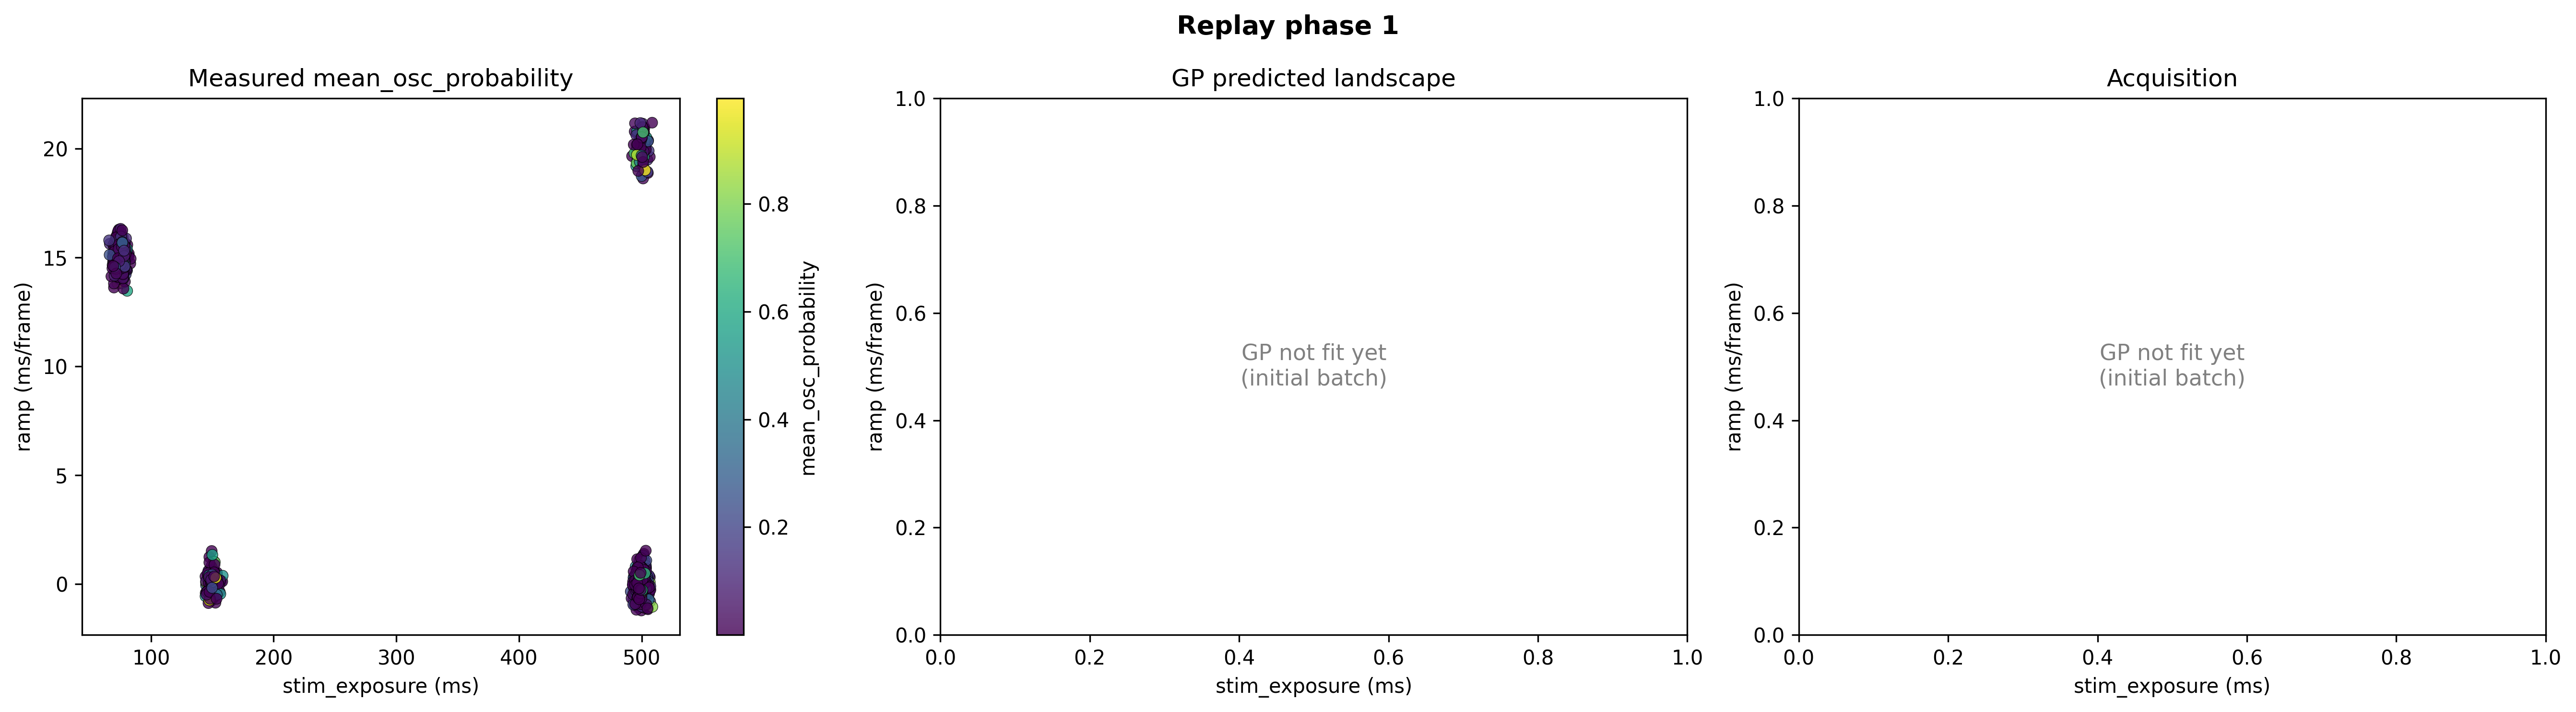


===== Replaying phase 2 =====
  Phase 2: 677 cells (from 18 FOVs), mean mean_osc_probability=0.1794, max=0.9969
  Fitting SingleTaskGP on 1617 observations (5-D)...
  Predicting 1900 points (95 grid x 20 cov samples)...
  Acq (ei): min=0.000000, max=0.010137
  Next suggested condition: {'stim_exposure': np.float64(200.0), 'ramp': np.float64(20.0)}
  _last_plot_context populated: True


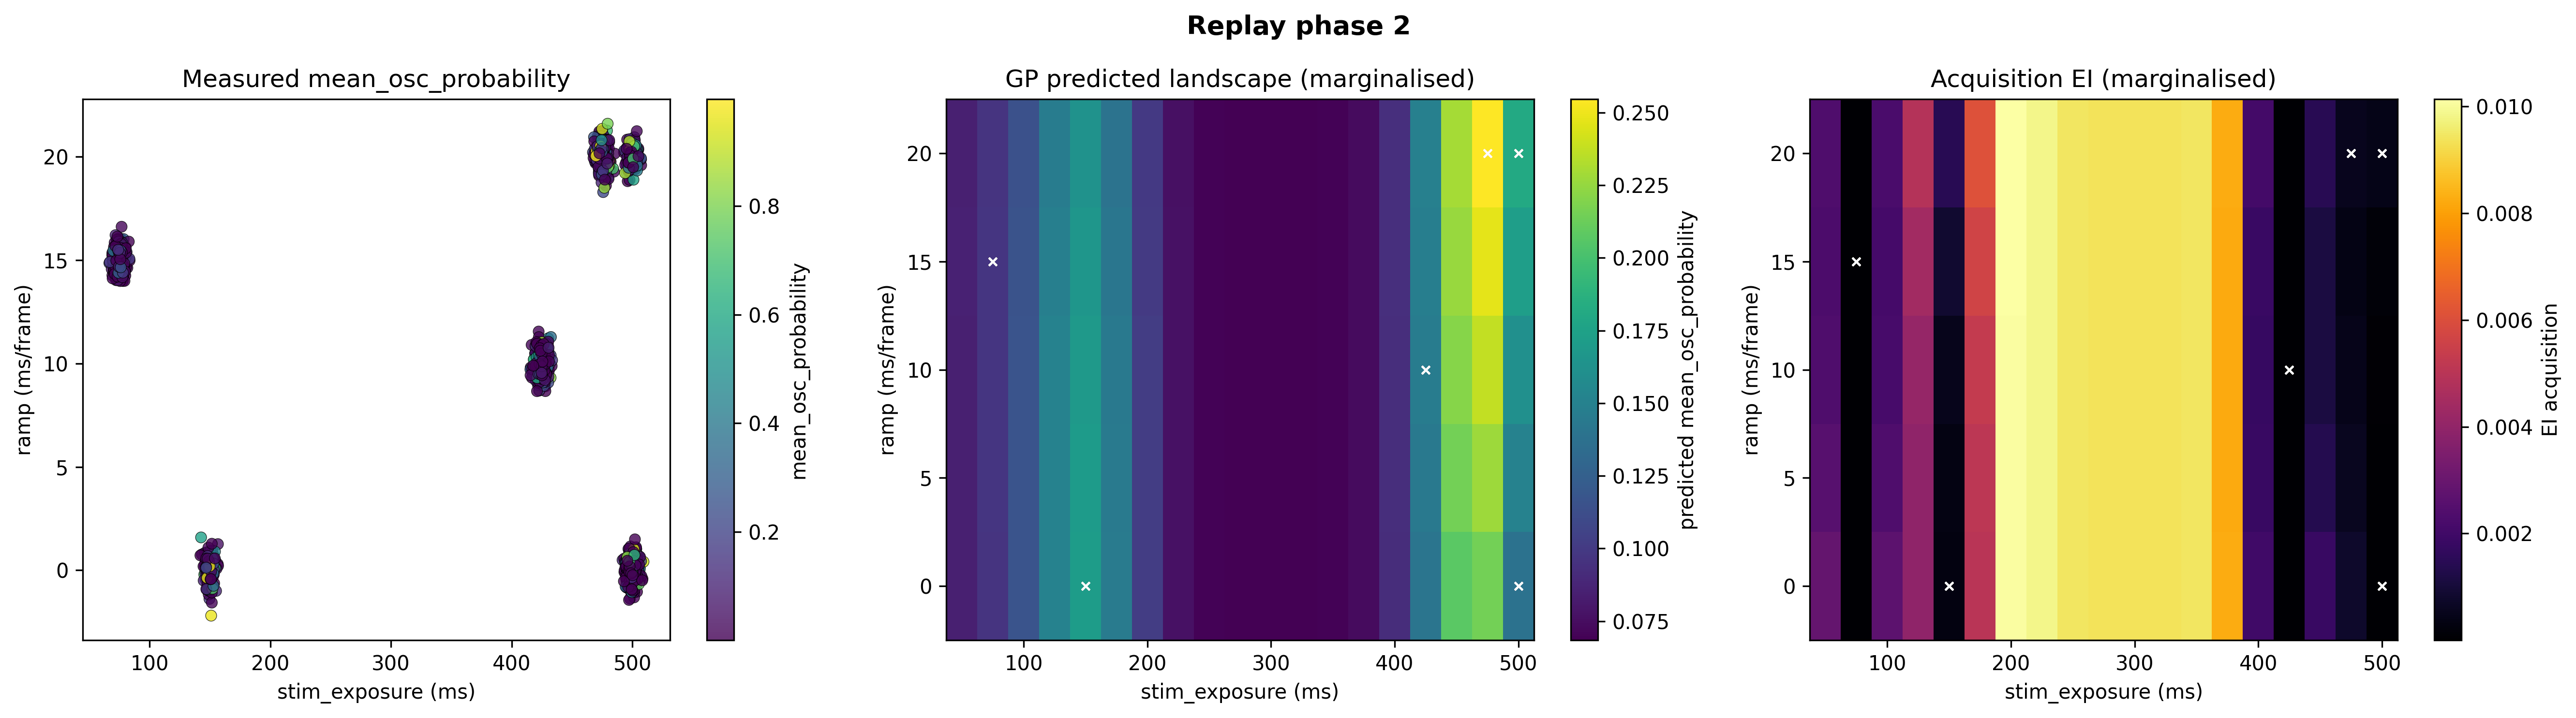


===== Replaying phase 3 =====
  Phase 3: 435 cells (from 18 FOVs), mean mean_osc_probability=0.2145, max=0.9926
  Fitting SingleTaskGP on 2052 observations (5-D)...
  Predicting 1880 points (94 grid x 20 cov samples)...
  Acq (ei): min=0.000000, max=0.010484
  Next suggested condition: {'stim_exposure': np.float64(325.0), 'ramp': np.float64(20.0)}
  _last_plot_context populated: True


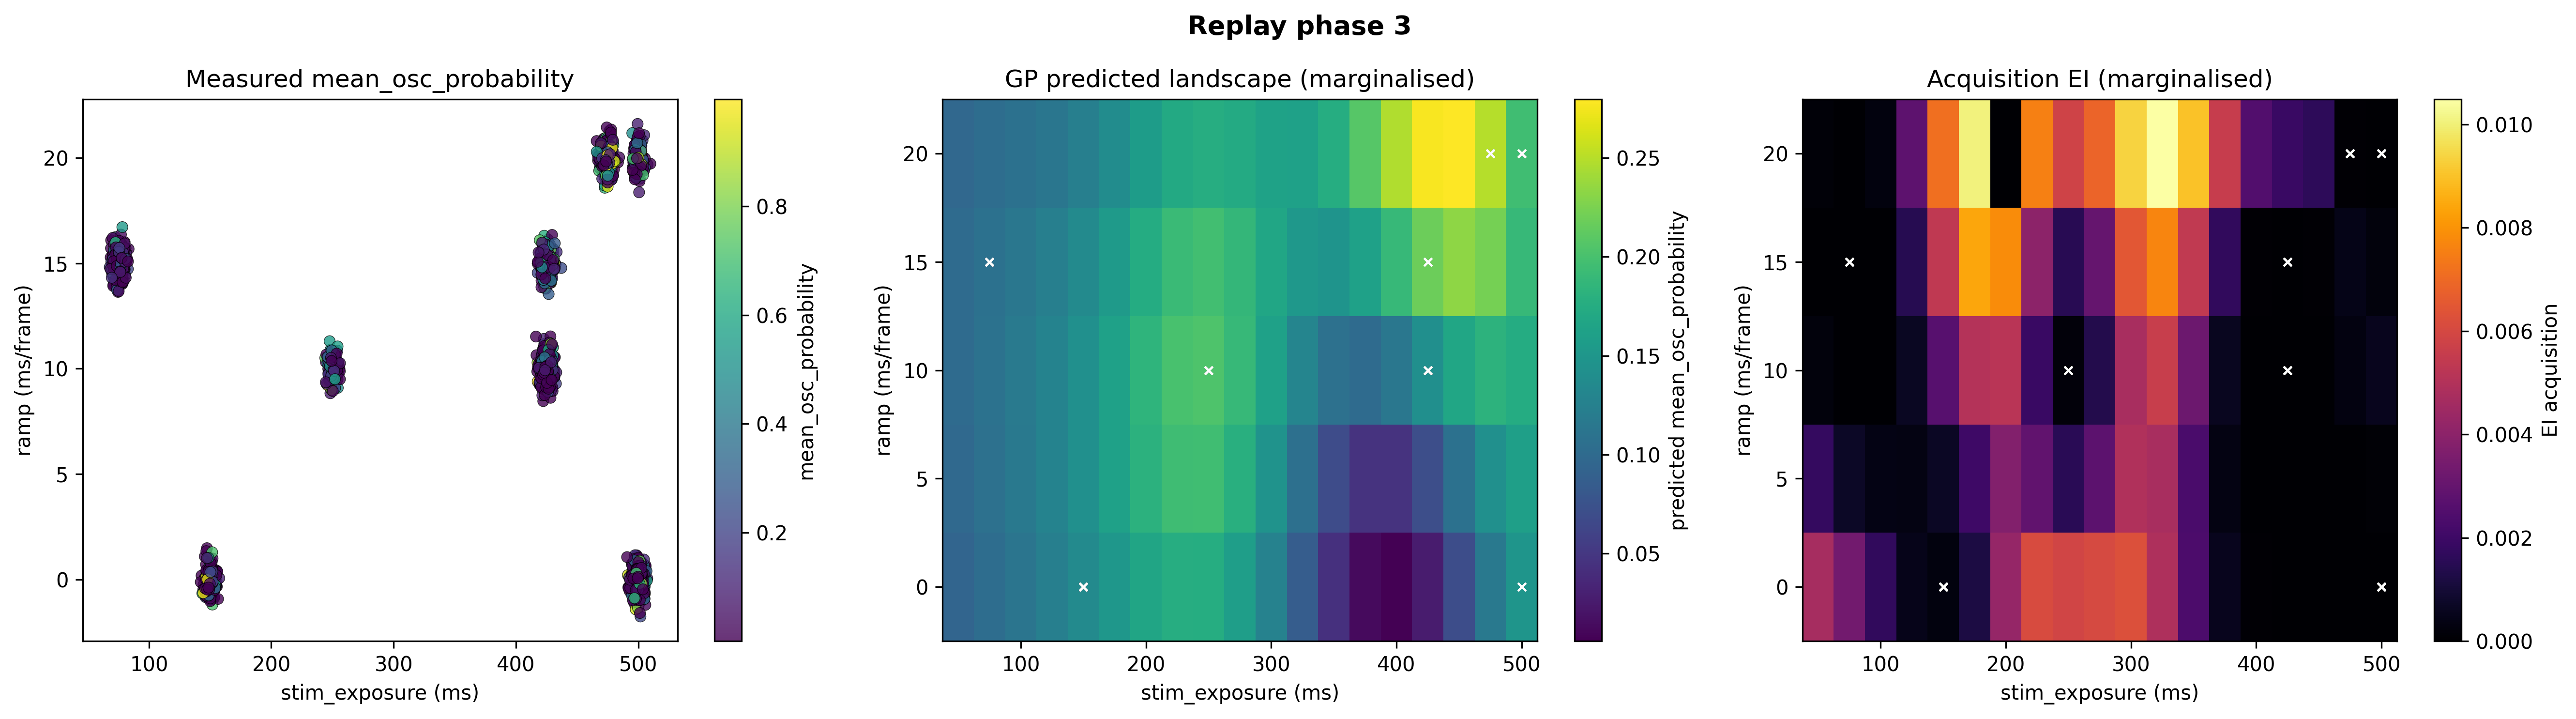


===== Replaying phase 4 =====
  Phase 4: 409 cells (from 18 FOVs), mean mean_osc_probability=0.2393, max=0.9976
  Fitting SingleTaskGP on 2461 observations (5-D)...
  Predicting 1860 points (93 grid x 20 cov samples)...
  Acq (ei): min=0.000000, max=0.003355
  Next suggested condition: {'stim_exposure': np.float64(350.0), 'ramp': np.float64(20.0)}
  _last_plot_context populated: True


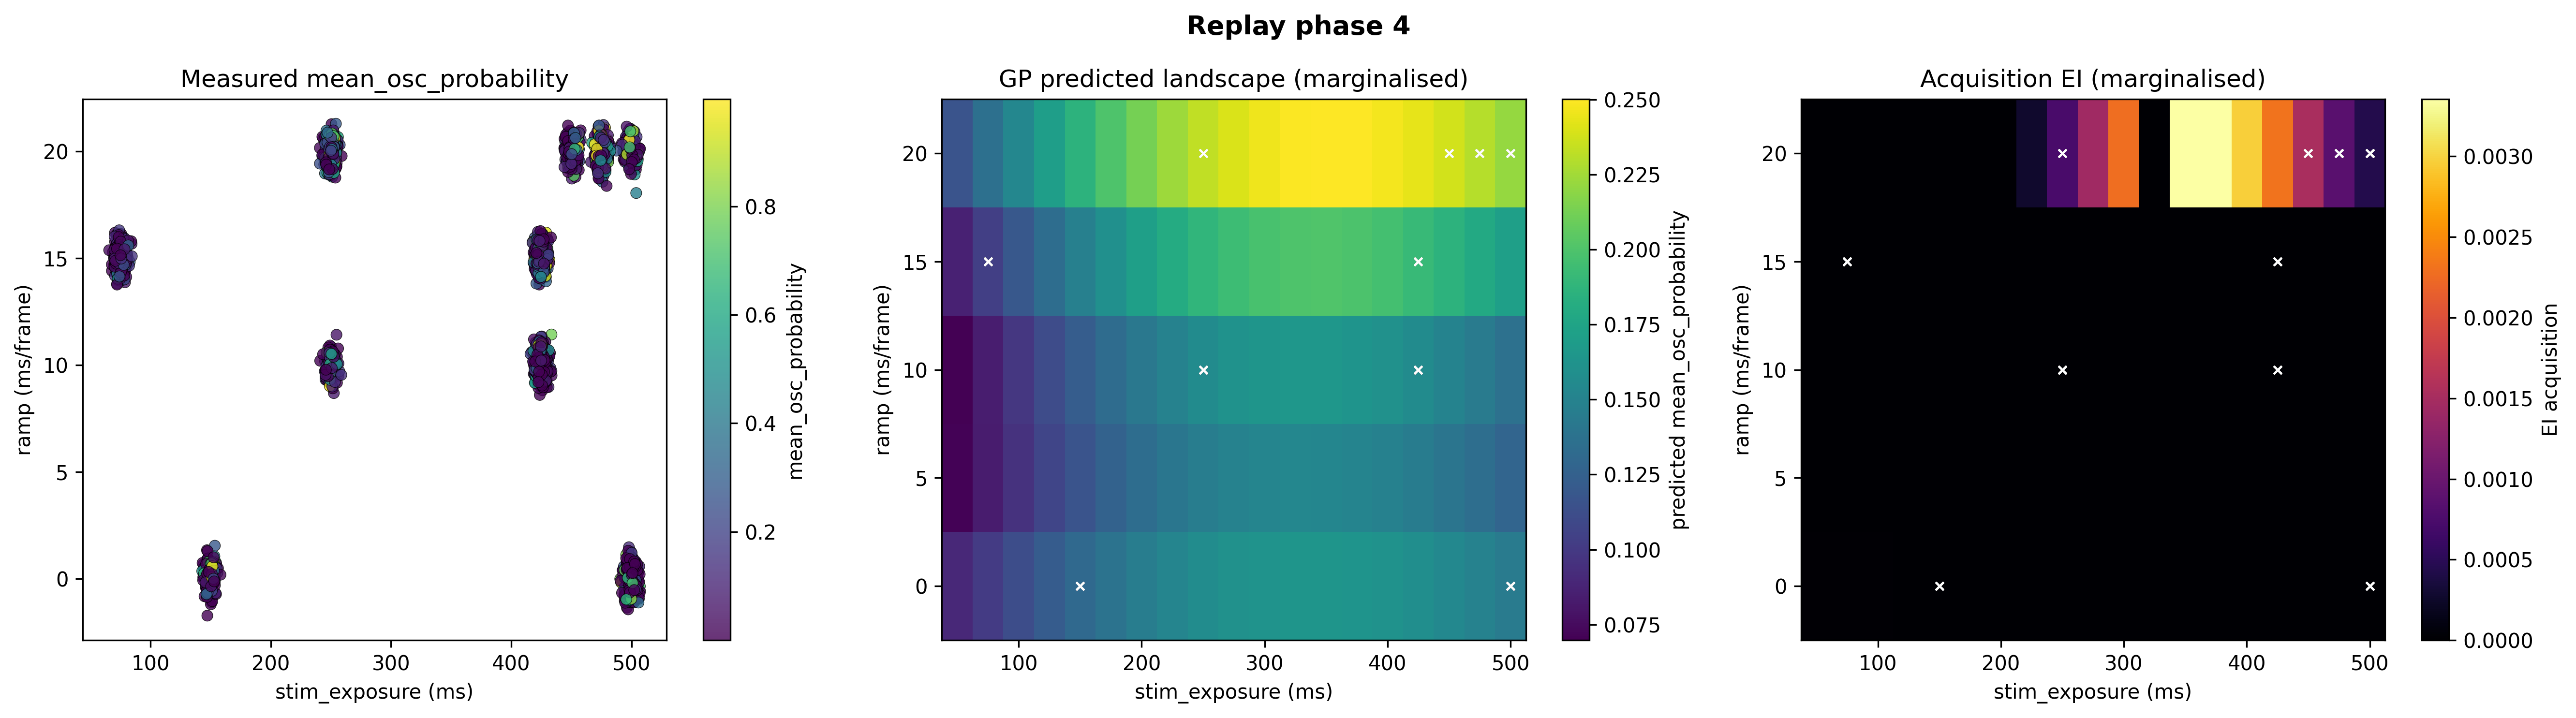


===== Replaying phase 5 =====
  Phase 5: 551 cells (from 18 FOVs), mean mean_osc_probability=0.1955, max=0.9980
  Fitting SingleTaskGP on 3012 observations (5-D)...
  Predicting 1840 points (92 grid x 20 cov samples)...
  Acq (ei): min=0.000000, max=0.007054
  Next suggested condition: {'stim_exposure': np.float64(400.0), 'ramp': np.float64(20.0)}
  _last_plot_context populated: True


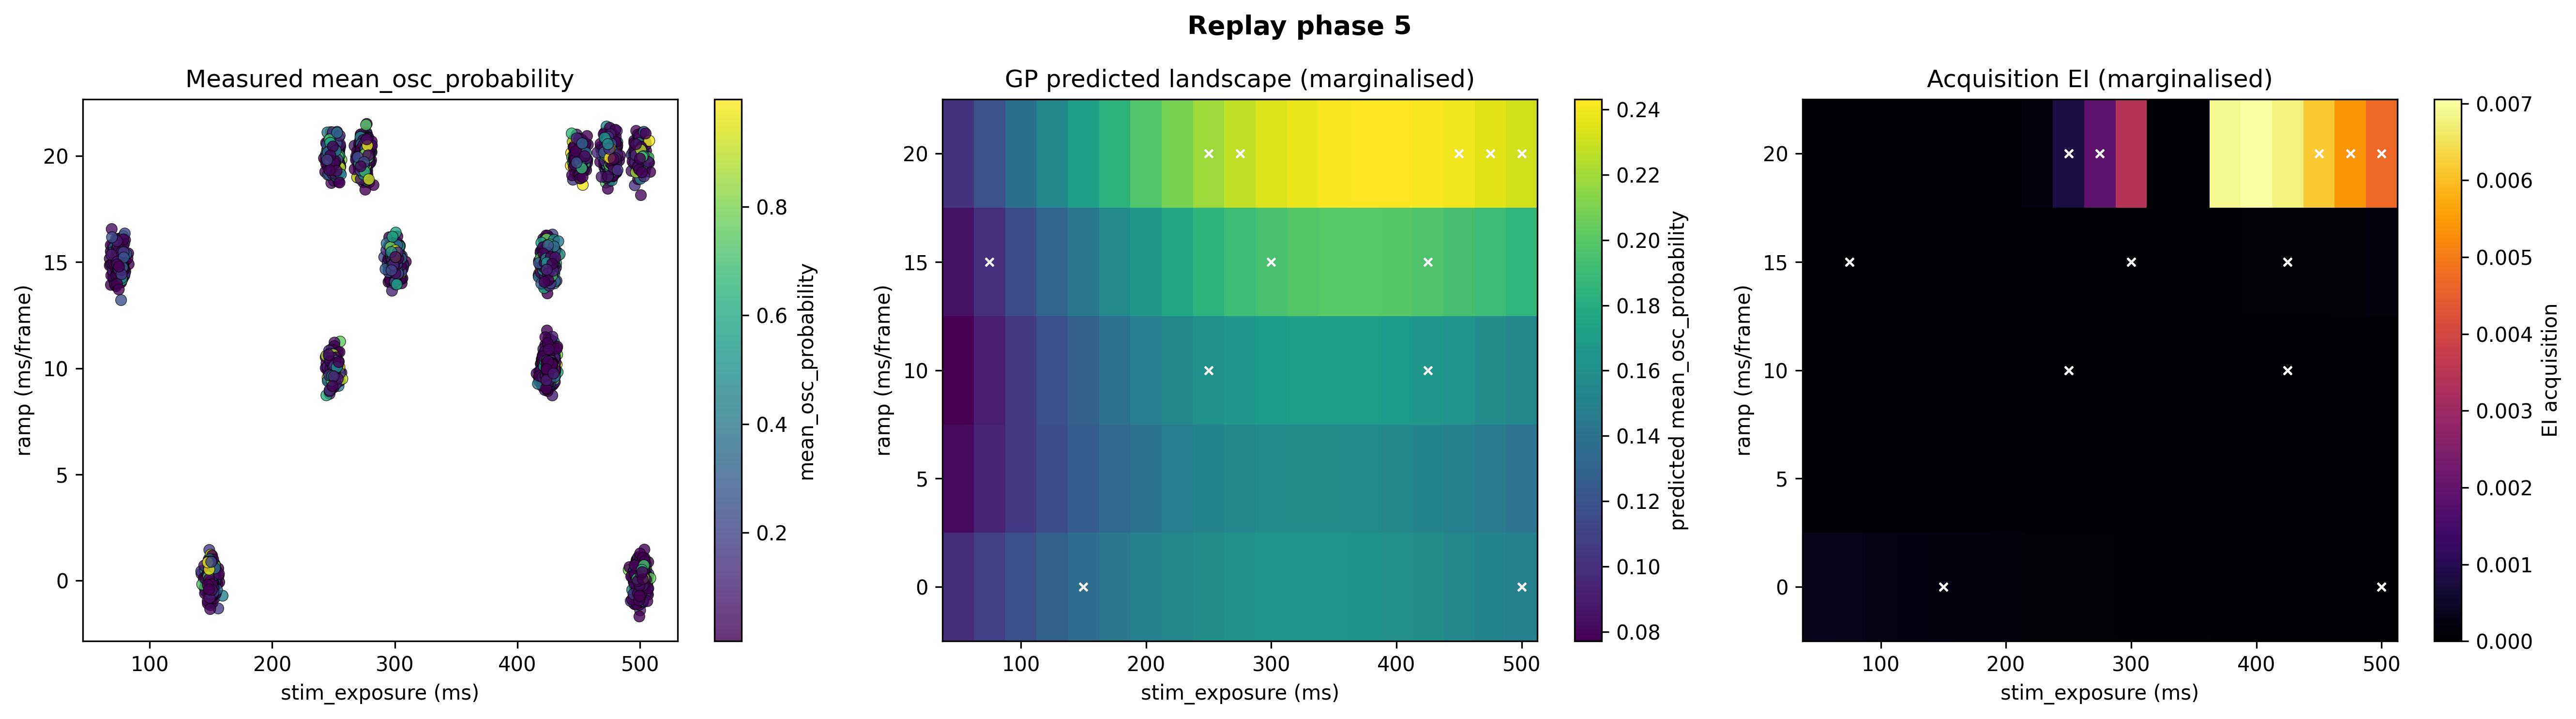


===== Replaying phase 6 =====
  Phase 6: 444 cells (from 18 FOVs), mean mean_osc_probability=0.2820, max=0.9901
  Fitting SingleTaskGP on 3456 observations (5-D)...
  Predicting 1820 points (91 grid x 20 cov samples)...
  Acq (ei): min=0.000056, max=0.026112
  Next suggested condition: {'stim_exposure': np.float64(375.0), 'ramp': np.float64(20.0)}
  _last_plot_context populated: True


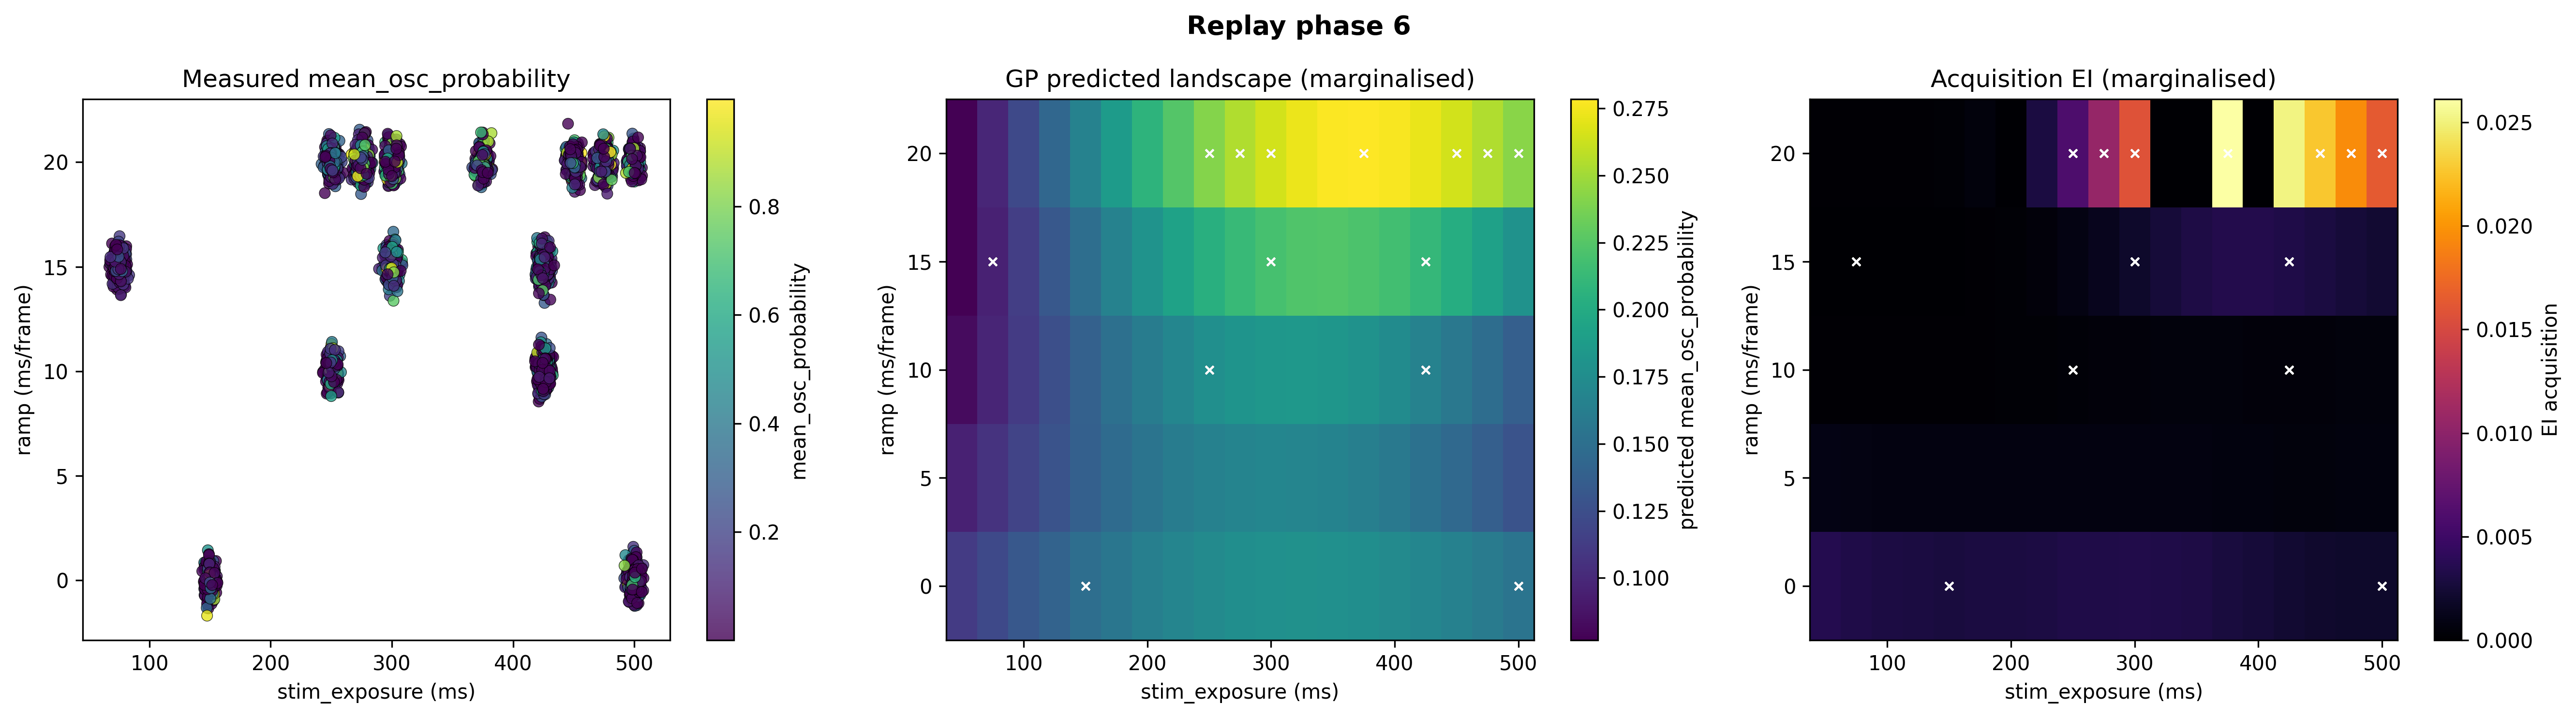


===== Replaying phase 7 =====
  Phase 7: 508 cells (from 18 FOVs), mean mean_osc_probability=0.1835, max=0.9977
  Fitting SingleTaskGP on 3964 observations (5-D)...
  Predicting 1800 points (90 grid x 20 cov samples)...
  Acq (ei): min=0.000001, max=0.026674
  Next suggested condition: {'stim_exposure': np.float64(425.0), 'ramp': np.float64(20.0)}
  _last_plot_context populated: True


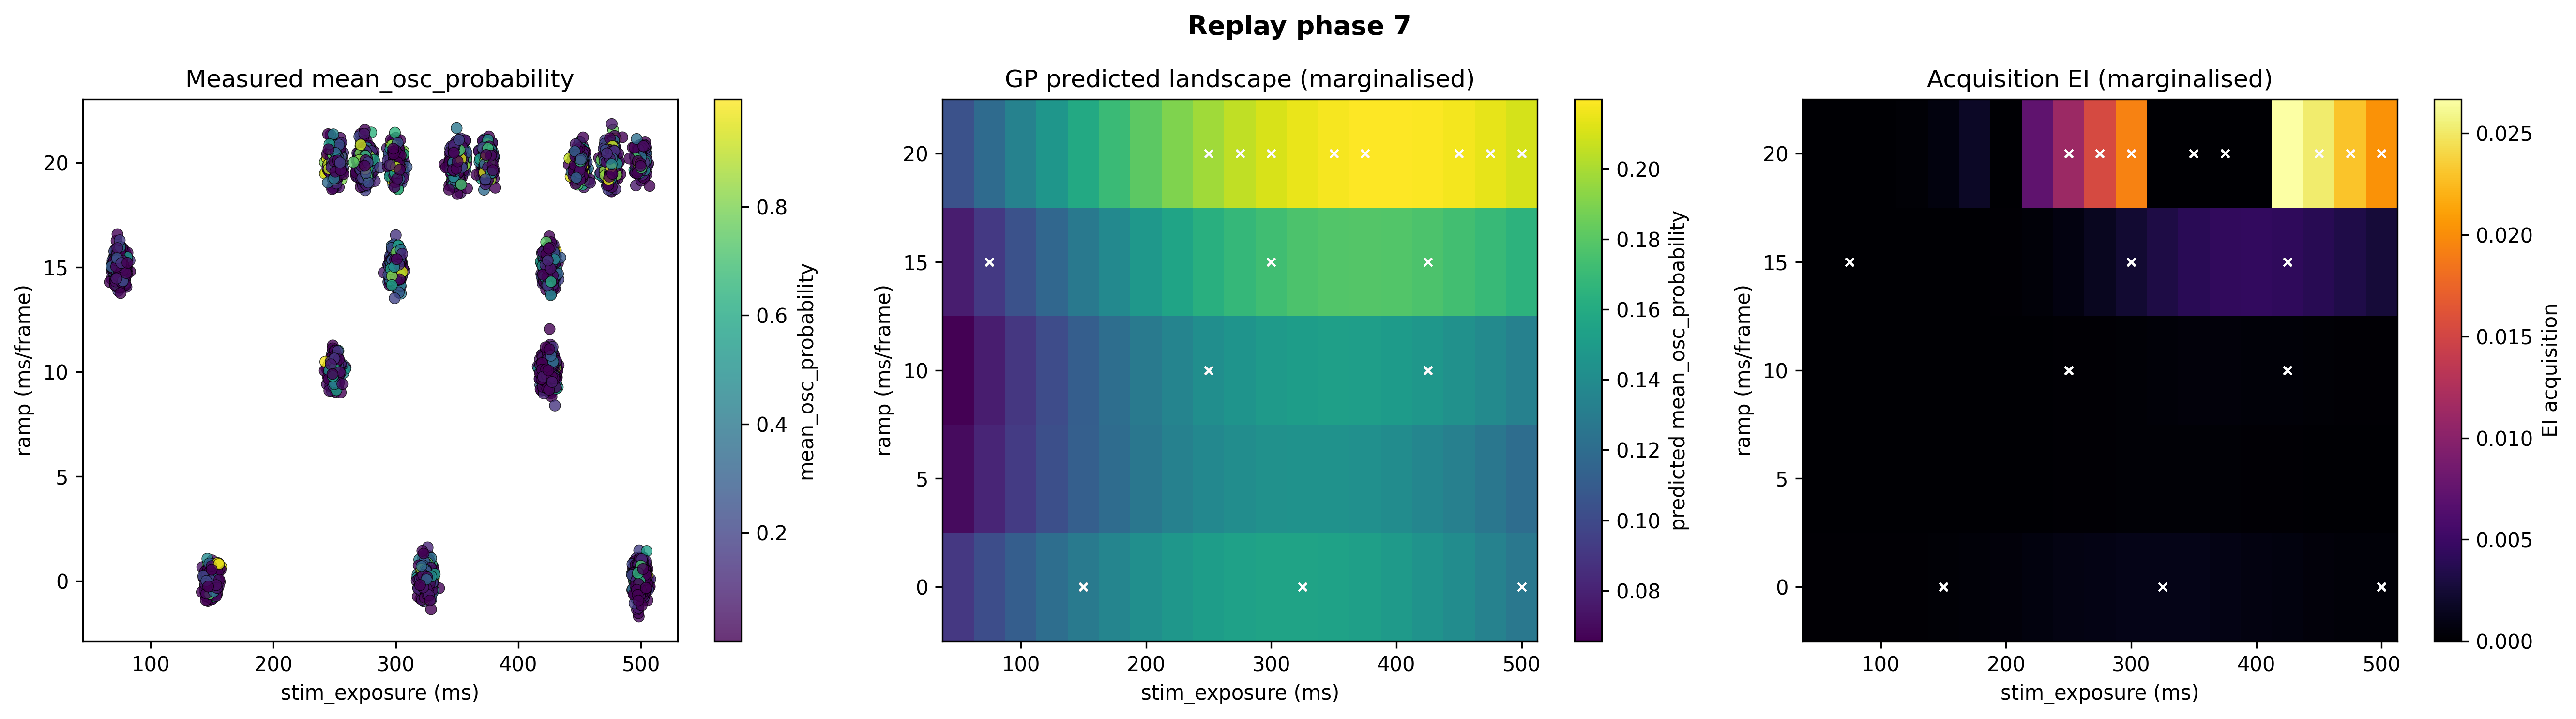


===== Replaying phase 8 =====
  Phase 8: 503 cells (from 18 FOVs), mean mean_osc_probability=0.1991, max=0.9808
  Fitting SingleTaskGP on 4467 observations (5-D)...
  Predicting 1780 points (89 grid x 20 cov samples)...
  Acq (ei): min=0.000005, max=0.033725
  Next suggested condition: {'stim_exposure': np.float64(175.0), 'ramp': np.float64(20.0)}
  _last_plot_context populated: True


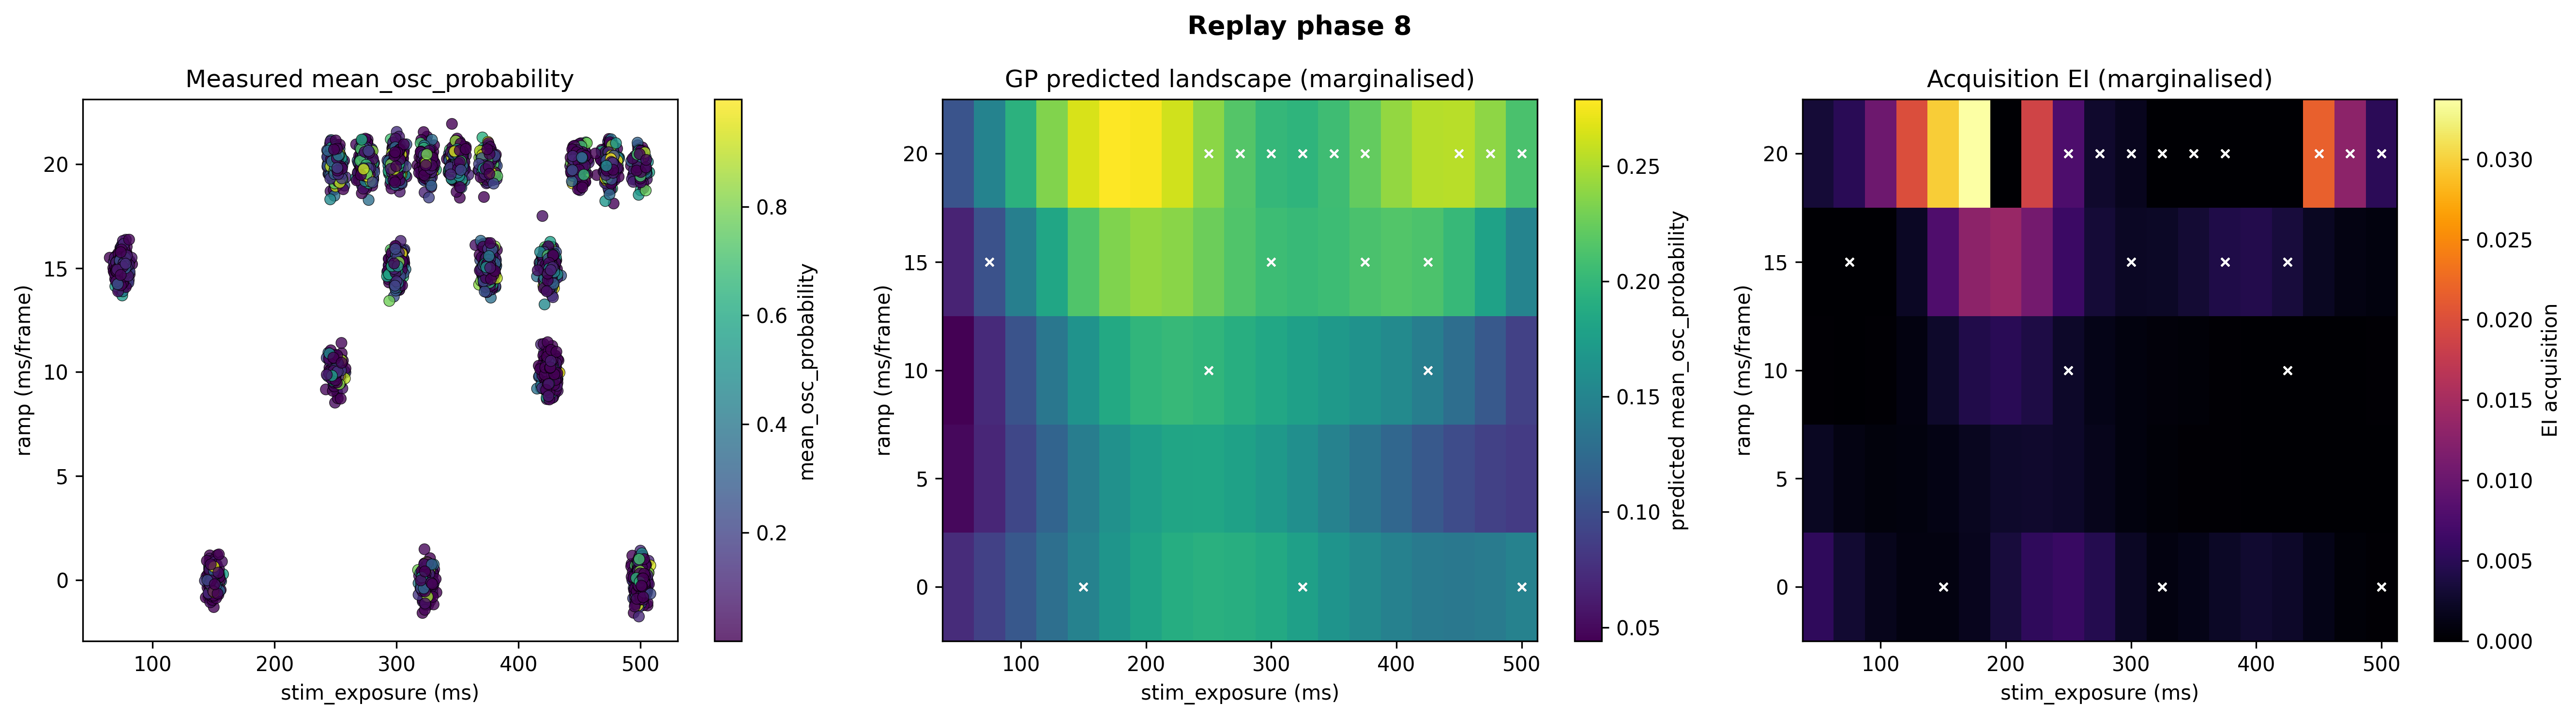

In [16]:
# --- Phase-by-phase replay ---
# For each phase: build a fake fov_tracks dict, call the single-cell
# preprocessor, append to df_results, fit GP (via _determine_next_parameters
# directly so errors are visible), and render the 1x3 plot.

agent._ensure_results_df()
phases = sorted(df_exp["phase_id"].unique())

for phase_id in phases:
    df_phase_raw = df_exp[df_exp["phase_id"] == phase_id]
    print(f"\n===== Replaying phase {phase_id} =====")

    fov_tracks = {
        int(fov): df_phase_raw[df_phase_raw["fov"] == fov].copy()
        for fov in df_phase_raw["fov"].unique()
    }

    cm = cond_map_df[cond_map_df["phase_id"] == phase_id]
    agent._current_condition_map = {
        int(row["fov"]): {
            "stim_exposure": float(row["stim_exposure"]),
            "ramp": float(row["ramp"]),
        }
        for _, row in cm.iterrows()
    }
    agent._current_phase_id = int(phase_id)

    # Per-cell preprocessing
    df_new = agent._preprocess_results(fov_tracks)
    if df_new.empty:
        print(f"  Phase {phase_id}: no cells; skipping")
        continue

    agent.df_results = pd.concat([agent.df_results, df_new], ignore_index=True)

    # Fit GP + compute acquisition. Directly call _determine_next_parameters
    # (instead of _select_batch_parameters) so any error SURFACES instead of
    # being swallowed, and so _last_plot_context is populated even with a
    # single-condition phase.
    if phase_id >= N_INITIAL_PHASES and len(agent.df_results) >= 4:
        agent.iteration = phase_id
        # Reset so we always re-populate for this phase (matches the
        # "is_first_call_in_batch" gate used inside the backend).
        agent._last_plot_context = None
        params = agent._determine_next_parameters(agent.df_results, verbose=True)
        print(f"  Next suggested condition: {params}")
        print(f"  _last_plot_context populated: {agent._last_plot_context is not None}")

    # Render the 1x3 live plot
    agent._plot_live(agent.df_results, f"Replay phase {phase_id}", save_subdir="replay")

In [17]:
# Final ARD lengthscales
dim_names = [p.name for p in agent.parameters_to_optimize] + [
    c.name for c in agent.bo_covariates
]

if agent.model is None:
    print("GP not fit yet (only initial-spread phases ran).")
elif USE_BOTORCH:
    import torch

    cm = agent.model.covar_module
    # BoTorch's SingleTaskGP may use RBFKernel/MaternKernel directly, or
    # wrap it in a ScaleKernel.  Unwrap if we see a ScaleKernel.
    kernel = getattr(cm, "base_kernel", cm)
    ls = kernel.lengthscale
    lengthscales = ls.detach().cpu().numpy().squeeze()
else:
    samples = agent.model.get_samples()
    lengthscales = np.asarray(samples["k_length"]).squeeze()

if agent.model is not None:
    rel = 1.0 / lengthscales
    rel /= rel.max()
    print("ARD lengthscales (small = highly relevant):")
    for name, lsv, r in sorted(zip(dim_names, lengthscales, rel), key=lambda t: t[1]):
        print(f"  {name:28s}  lengthscale={lsv:6.3f}   relative_relevance={r:.2f}")

ARD lengthscales (small = highly relevant):
  optortk_expression            lengthscale= 0.025   relative_relevance=1.00
  stim_exposure                 lengthscale= 0.291   relative_relevance=0.09
  mean_dist_k_nearest           lengthscale= 0.405   relative_relevance=0.06
  ramp                          lengthscale= 0.644   relative_relevance=0.04
  baseline_cnr                  lengthscale= 1.803   relative_relevance=0.01


## GP sanity check: how trustworthy is the fitted model?

Three metrics, computed on the **training set** (cheap) and on a
**held-out phase** (honest generalisation check):

| Metric | Interpretation | Good value |
|---|---|---|
| `R²` | Fraction of variance explained | 0.3–0.9 for noisy biology |
| `RMSE` | Avg prediction error in target units | Compare to target's std |
| `NLPD` | Neg log predictive density (proper scoring rule) | Lower = better |
| `95% coverage` | Fraction of obs inside predicted 95% CI | ≈ 0.95 (else mis-calibrated) |
| `Residual z-score std` | Std of `(y - μ) / σ` | ≈ 1.0 (else under/over-confident) |

Flags to watch:
- **R² ≈ 0** → GP is just predicting the mean; objective is noise-dominated
  or covariates/parameters don't explain the signal.
- **Coverage ≫ 0.95** → over-confident posterior (tiny σ). The BO will
  stop exploring prematurely.
- **Coverage ≪ 0.95** → under-confident posterior. BO wastes budget
  on random exploration.
- **Residual z-score std ≫ 1** → GP thinks it's precise but isn't.
  Often means noise variance is under-fit.
- **Holdout RMSE ≫ train RMSE** → over-fit to training set.

In [18]:
# --- Training-set diagnostics (cheap, uses the already-fit GP) ---
# Predict on the same (x, c) rows used for fitting, compare to y_obs.


def _predict_observed_units(model, X_raw):
    # Return (mean, std) in OBSERVED units, regardless of backend.
    if USE_BOTORCH:
        import torch

        # BoTorch model has Normalize/Standardize built-in, so we pass
        # the raw (log-transformed where declared) input and get mean/var
        # already in observed units.
        x_transformed = agent._apply_log_transforms(X_raw)
        Xp = torch.tensor(x_transformed, dtype=torch.double)
        with torch.no_grad():
            post = model.posterior(Xp)
            mean = post.mean.squeeze(-1).numpy()
            var = post.variance.squeeze(-1).numpy()
        # Apply objective log-transform inverse if declared
        if agent.objective_metric.log_scale:
            mean = np.exp(mean)
            # crude std mapping under log-transform (fine for small std)
            var = var * (mean**2)
        return mean, np.sqrt(np.maximum(var, 1e-12))

    # gpax viSparseGP / viGP: scale X, predict, unscale mean/var
    X_scaled = np.asarray(agent._x_scaler.transform(X_raw))
    mean_s, var_s = model.predict_in_batches(
        getattr(agent, "_rng_key_predict", None),
        X_scaled,
        batch_size=agent.gp_batch_size,
        noiseless=True,
    )
    mean_s = np.asarray(mean_s).flatten()
    var_s = np.asarray(var_s).flatten()
    mean = agent._y_scaler.inverse_transform(mean_s.reshape(-1, 1)).flatten()
    y_std_scale = float(np.abs(np.asarray(agent._y_scaler.std_)[0]))
    std = np.sqrt(np.maximum(var_s, 1e-12)) * y_std_scale
    return mean, std


def _gp_diagnostics(df_train, df_test=None, label="train"):
    cols = [p.name for p in agent.parameters_to_optimize] + [
        c.name for c in agent.bo_covariates
    ]
    y_name = agent.objective_metric.name

    target_df = df_test if df_test is not None else df_train
    X_raw = target_df[cols].to_numpy(dtype=float)
    y_raw = target_df[y_name].to_numpy(dtype=float)

    mean, std = _predict_observed_units(agent.model, X_raw)

    resid = y_raw - mean
    ss_res = float(np.sum(resid**2))
    ss_tot = float(np.sum((y_raw - y_raw.mean()) ** 2))
    r2 = 1.0 - ss_res / max(ss_tot, 1e-12)
    rmse = float(np.sqrt(ss_res / max(len(y_raw), 1)))

    nlpd = float(
        np.mean(0.5 * np.log(2 * np.pi * std**2) + 0.5 * (resid**2) / (std**2))
    )

    lo = mean - 1.96 * std
    hi = mean + 1.96 * std
    coverage = float(np.mean((y_raw >= lo) & (y_raw <= hi)))

    z = resid / np.maximum(std, 1e-12)
    z_std = float(np.std(z))

    print(f"--- {label} (n={len(y_raw)}) ---")
    print(f"  R2                = {r2:6.3f}")
    print(f"  RMSE              = {rmse:6.4f}   (target std = {y_raw.std():.4f})")
    print(f"  NLPD              = {nlpd:6.3f}")
    print(f"  95% coverage      = {coverage:6.3f}  (target ~0.95)")
    print(f"  z-score std       = {z_std:6.3f}   (target ~1.0)")
    return dict(
        r2=r2,
        rmse=rmse,
        nlpd=nlpd,
        coverage=coverage,
        z_std=z_std,
        mean=mean,
        std=std,
        y=y_raw,
    )


print("\n=== Training-set diagnostics ===")
train_diag = _gp_diagnostics(agent.df_results, df_test=None, label="train")


=== Training-set diagnostics ===
--- train (n=4467) ---
  R2                =  0.142
  RMSE              = 0.2456   (target std = 0.2652)
  NLPD              = 86.001
  95% coverage      =  0.209  (target ~0.95)
  z-score std       = 13.329   (target ~1.0)


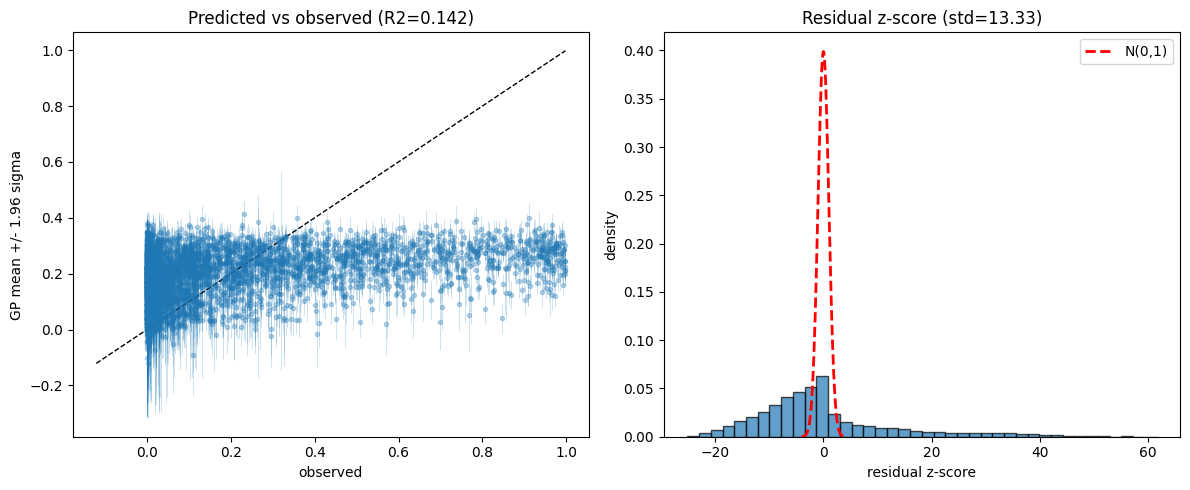

In [19]:
# --- Predicted vs observed + residual histogram ---
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

m, y = train_diag["mean"], train_diag["y"]
s = train_diag["std"]
axes[0].errorbar(y, m, yerr=1.96 * s, fmt="o", alpha=0.3, ms=3, lw=0.5)
lo, hi = min(y.min(), m.min()), max(y.max(), m.max())
axes[0].plot([lo, hi], [lo, hi], "k--", lw=1)
axes[0].set_xlabel("observed")
axes[0].set_ylabel("GP mean +/- 1.96 sigma")
axes[0].set_title(f"Predicted vs observed (R2={train_diag['r2']:.3f})")

z = (y - m) / np.maximum(s, 1e-12)
axes[1].hist(z, bins=40, density=True, alpha=0.7, edgecolor="black")
xx = np.linspace(-4, 4, 200)
axes[1].plot(xx, np.exp(-(xx**2) / 2) / np.sqrt(2 * np.pi), "r--", lw=2, label="N(0,1)")
axes[1].set_xlabel("residual z-score")
axes[1].set_ylabel("density")
axes[1].set_title(f"Residual z-score (std={train_diag['z_std']:.2f})")
axes[1].legend()

plt.tight_layout()
plt.show()

### Honest generalisation: hold out the last phase

Re-fits the GP on phases 0..N-1 and predicts the held-out phase N cells.
This tests "would the GP have correctly predicted the next batch?" —
the actual ability the BO relies on when it picks the next condition.

Slow (one full GP refit). Skip if you just want a quick sanity check
— the training-set diagnostics above are a reasonable upper bound on
how well the model fits, and the plots + residual histogram are
usually enough.

Holdout phase 8: train n=3964, test n=503
Refitting GP on train split only...
  Fitting SingleTaskGP on 3964 observations (5-D)...
  Predicting 1760 points (88 grid x 20 cov samples)...

=== Holdout diagnostics (phase N predicted from phases 0..N-1) ===
--- holdout (n=503) ---
  R2                =  0.065
  RMSE              = 0.2642   (target std = 0.2732)
  NLPD              = 219.185
  95% coverage      =  0.117  (target ~0.95)
  z-score std       = 21.057   (target ~1.0)

=== Train diagnostics (reduced train set only, for comparison) ===
--- train-reduced (n=3964) ---
  R2                =  0.131
  RMSE              = 0.2462   (target std = 0.2641)
  NLPD              = 144.537
  95% coverage      =  0.170  (target ~0.95)
  z-score std       = 17.182   (target ~1.0)


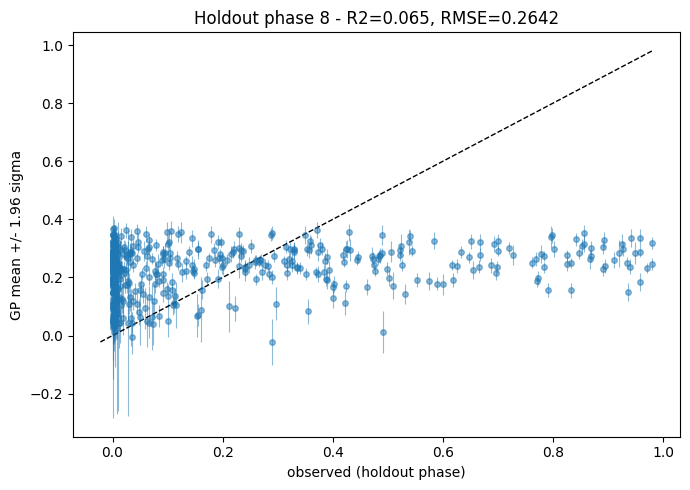

In [20]:
# --- Hold-out-phase generalisation (slow: one GP refit) ---
HOLDOUT_PHASE = max(phases)  # last phase by default

df_train = agent.df_results[agent.df_results["phase_id"] != HOLDOUT_PHASE]
df_test = agent.df_results[agent.df_results["phase_id"] == HOLDOUT_PHASE]

if df_train.empty or df_test.empty:
    print(f"Can't hold out phase {HOLDOUT_PHASE}: empty split")
else:
    print(
        f"Holdout phase {HOLDOUT_PHASE}: train n={len(df_train)}, test n={len(df_test)}"
    )
    print("Refitting GP on train split only...")

    agent._last_plot_context = None
    _ = agent._determine_next_parameters(df_train, verbose=False)

    print("\n=== Holdout diagnostics (phase N predicted from phases 0..N-1) ===")
    holdout_diag = _gp_diagnostics(df_train, df_test=df_test, label="holdout")

    print("\n=== Train diagnostics (reduced train set only, for comparison) ===")
    train_reduced_diag = _gp_diagnostics(df_train, df_test=None, label="train-reduced")

    fig, ax = plt.subplots(figsize=(7, 5))
    m = holdout_diag["mean"]
    y = holdout_diag["y"]
    s = holdout_diag["std"]
    ax.errorbar(y, m, yerr=1.96 * s, fmt="o", alpha=0.5, ms=4, lw=0.8)
    lo, hi = min(y.min(), m.min()), max(y.max(), m.max())
    ax.plot([lo, hi], [lo, hi], "k--", lw=1)
    ax.set_xlabel("observed (holdout phase)")
    ax.set_ylabel("GP mean +/- 1.96 sigma")
    ax.set_title(
        f"Holdout phase {HOLDOUT_PHASE} - R2={holdout_diag['r2']:.3f}, "
        f"RMSE={holdout_diag['rmse']:.4f}"
    )
    plt.tight_layout()
    plt.show()